1. Business Objective

Optimize a stock portfolio by Maximizing expected return, Minimizing risk (volatility) and Finding optimal asset weight

In [11]:
pip install numpy pandas matplotlib scipy


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize


In [3]:
# Load stock price data
file_path = "/content/drive/MyDrive/stock_Portfolio optimization 19.2.26.csv"
data = pd.read_csv(file_path, index_col=0, parse_dates=True)

# Display first rows
print(data.head())


            Bank of America  General Electric  Chesapeake Energy   AT&T  \
Date                                                                      
2007-12-31            40.91             37.08              39.36  42.12   
2008-03-31            38.18             36.63              45.76  37.71   
2008-06-30            24.74             26.35              66.77  32.75   
2008-09-30            32.40             23.87              33.29  28.35   
2008-12-31            13.09             15.82              15.34  28.19   

            Cisco Systems  Marvel  Campbell Soup  
Date                                              
2007-12-31          27.25   14.02          35.77  
2008-03-31          24.08   11.08          33.91  
2008-06-30          23.47   17.69          33.03  
2008-09-30          22.25    8.80          38.30  
2008-12-31          16.18    6.54          29.49  


In [4]:
# Daily returns
returns = data.pct_change().dropna()

# Mean returns and covariance matrix
mean_returns = returns.mean()
cov_matrix = returns.cov()
num_assets = len(mean_returns)


In [5]:
#portfolio functions
def portfolio_performance(weights, mean_returns, cov_matrix):
    portfolio_return = np.sum(mean_returns * weights) * 252
    portfolio_volatility = np.sqrt(
        np.dot(weights.T, np.dot(cov_matrix * 252, weights))
    )
    return portfolio_return, portfolio_volatility



In [6]:
#Sharpe ratio Function
def negative_sharpe_ratio(weights, mean_returns, cov_matrix, risk_free_rate=0.01):
    p_return, p_volatility = portfolio_performance(weights, mean_returns, cov_matrix)
    return -(p_return - risk_free_rate) / p_volatility


The Sharpe ratio measures the risk-adjusted performance of an investment by dividing its excess return (portfolio return minus risk-free rate) by the standard deviation of its returns. It indicates how well an asset compensates investors for the risk taken, with a higher ratio suggesting better performance.
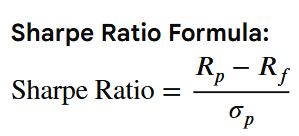




Rp: Expected Portfolio Return

Rf: Risk-Free Rate of Return

: Standard Deviation of Portfolio Returns (Volatility)

In [7]:
#Constraints & Bounds
# Constraint: sum of weights = 1
constraints = {'type': 'eq', 'fun': lambda x: np.sum(x) - 1}

# Bounds: between 0 and 1 (no short selling)
bounds = tuple((0, 1) for _ in range(num_assets))

# Initial guess
initial_weights = num_assets * [1. / num_assets]


In [8]:
#Optimization
optimized = minimize(
    negative_sharpe_ratio,
    initial_weights,
    args=(mean_returns, cov_matrix),
    method='SLSQP',
    bounds=bounds,
    constraints=constraints
)

optimal_weights = optimized.x


In [9]:
opt_return, opt_volatility = portfolio_performance(
    optimal_weights, mean_returns, cov_matrix
)

print("Optimal Portfolio Weights:")
for stock, weight in zip(data.columns, optimal_weights):
    print(f"{stock}: {weight:.4f}")

print("\nExpected Annual Return:", round(opt_return, 4))
print("Annual Volatility (Risk):", round(opt_volatility, 4))
print("Sharpe Ratio:", round(opt_return / opt_volatility, 4))


Optimal Portfolio Weights:
Bank of America: 0.1156
General Electric: 0.0000
Chesapeake Energy: 0.0000
AT&T: 0.0000
Cisco Systems: 0.3570
Marvel: 0.3016
Campbell Soup: 0.2258

Expected Annual Return: 5.9475
Annual Volatility (Risk): 1.8603
Sharpe Ratio: 3.1971


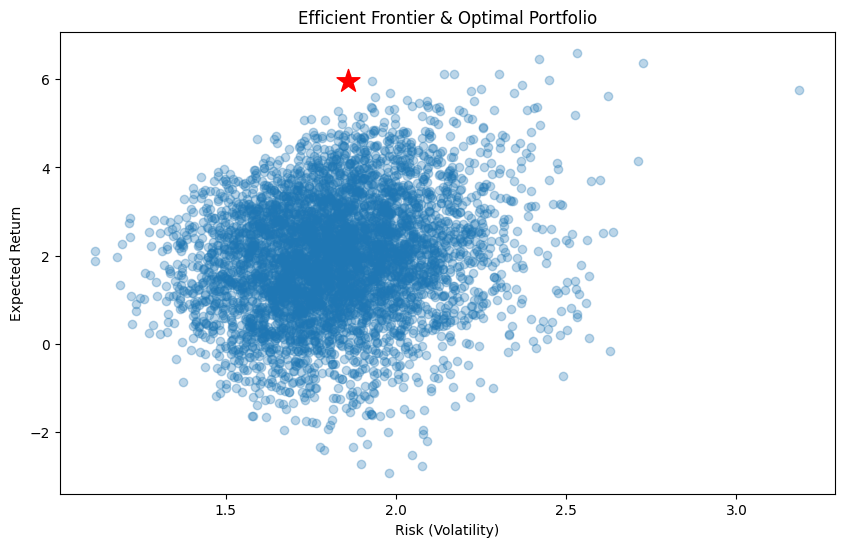

In [10]:
portfolio_returns = []
portfolio_volatility = []

for _ in range(5000):
    weights = np.random.random(num_assets)
    weights /= np.sum(weights)

    ret, vol = portfolio_performance(weights, mean_returns, cov_matrix)
    portfolio_returns.append(ret)
    portfolio_volatility.append(vol)

plt.figure(figsize=(10, 6))
plt.scatter(portfolio_volatility, portfolio_returns, alpha=0.3)
plt.scatter(opt_volatility, opt_return, color='red', marker='*', s=300)
plt.xlabel('Risk (Volatility)')
plt.ylabel('Expected Return')
plt.title('Efficient Frontier & Optimal Portfolio')
plt.show()


Interpretation

Optimal weights show how much to invest in each stock

Higher Sharpe Ratio = better risk-adjusted return

Red star = best portfolio